# Practica 3
## *Filtrado de imágenes en escala de grises*

Autor:
 - Adrián Redondo García

---

# Introducción

En esta práctica, vamos a evaluar cómo distintos filtros nos pueden ayudar a reducir el ruido que pueda haber en una imagen, ya que en situaciones en la vida real, en el procesamiento de imágenes éstas no estarán siempre limpias y bien definidas.

La imagen con la que trabajaremos será la siguiente:

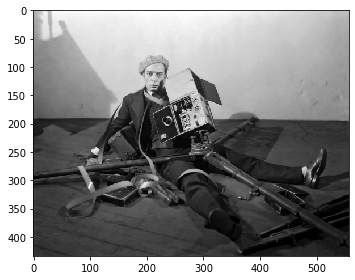

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
from skimage import io, img_as_float
from skimage.color import rgb2gray

image = io.imread('Cameraman.png')

io.imshow(image)

---

# Añadiendo ruido a la imagen original

Antes de poder probar los filtros en la imagen, la añadiremos ruido gaussiano. Primero verificaremos que la imagen está en blanco y negro revisando sus dimensiones asegurándonos que tiene dos.

In [12]:
print(image.shape)

(434, 557, 3)


Vemos que aparte de las filas y las columnas, nos indica cuantos canales de color tiene la imagen, algo que no debería estar. Se lo podemos quitar con la siguiente función:

In [13]:
image = rgb2gray(image)

print(image.shape)

(434, 557)


Una vez modificada la imagen para que no tenga canales de color, podemos añadir el ruido gaussiano.

Podemos modificar cómo se aplica el ruido modificando la media y la desviación típica.

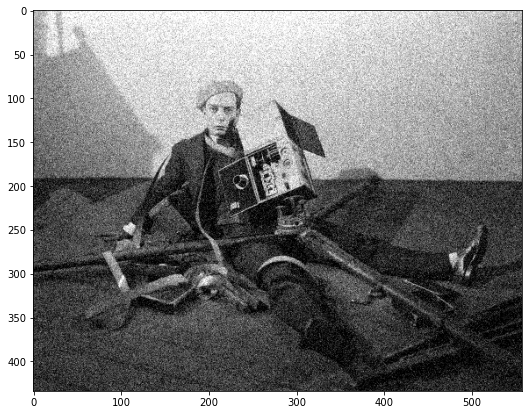

In [14]:
image = img_as_float(image)

media = 0
varianza = 0.01
des_tipica = varianza ** 0.5

ruido = np.random.normal(media, des_tipica, image.shape)
img_ruidosa = image + ruido
img_ruidosa = np.clip(img_ruidosa, 0.0, 1.0)

fig = plt.figure(figsize=(12,7))
ax1 = fig.add_subplot(111)
ax1.imshow(img_ruidosa, cmap="gray")

Una vez añadido el ruido a la imagen, podemos probar los distintos filtros.

---

# Filtros

Los filtros que veremos serán:
 - Filtro de media
 - Filtro de mediana
 - Filtro gaussiano
 - Filtro anisotrópico

## Filtro de media

El filtro de media para eliminar el ruido de la imagen define un tamaño fijo de píxeles (puede ser 3x3, 5x5), preferiblemente un número impar para tener un pixel central y calculando la media del valor de cada pixel que rodea al pixel central.

El efecto que tiene es reducir el ruido de la imagen de forma global, pero hace que la imagen se vea más borrosa y con menos definición.

Se puede apreciar en la siguiente comparación:

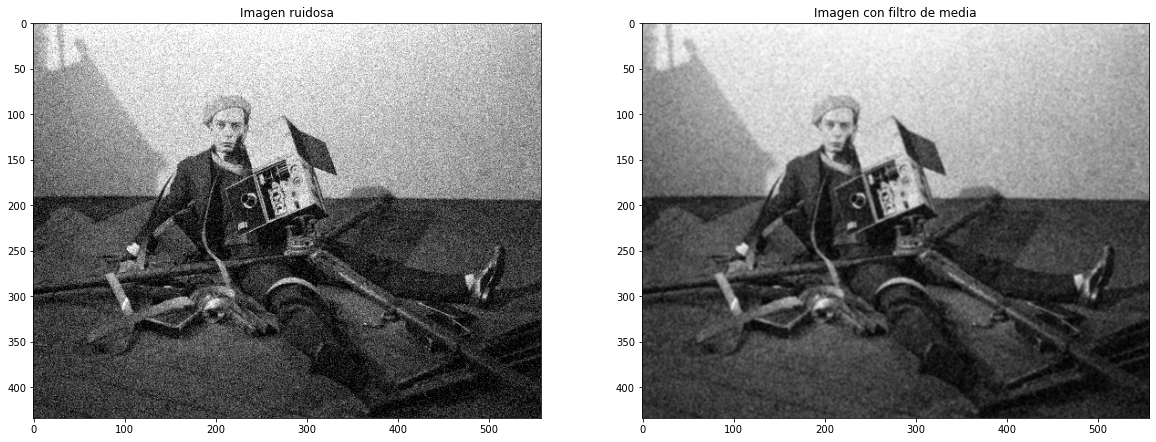

In [15]:
img_media = ndimage.uniform_filter(img_ruidosa, size=3)

fig = plt.figure(figsize=(20,15))

ax1 = fig.add_subplot(121)
ax1.set_title("Imagen ruidosa")

ax2 = fig.add_subplot(122)
ax2.set_title("Imagen con filtro de media")

ax1.imshow(img_ruidosa, cmap="gray")
ax2.imshow(img_media, cmap="gray")

plt.show()

Se puede ver que el ruido se ha reducido, pero la imagen se ve más borrosa.

## Filtro de mediana

El filtro de mediana funciona de manera similar al filtro de media, solo que en vez de calcular el nuevo pixel mediante la media, se usa la mediana de los píxeles que rodean al pixel central.

Conserva mejor los bordes que el filtro de media, pero puede hacer que no todo el ruido desaparezca del todo en zonas muy amplias de la imagen.

Se puede apreciar en la siguiente comparación:

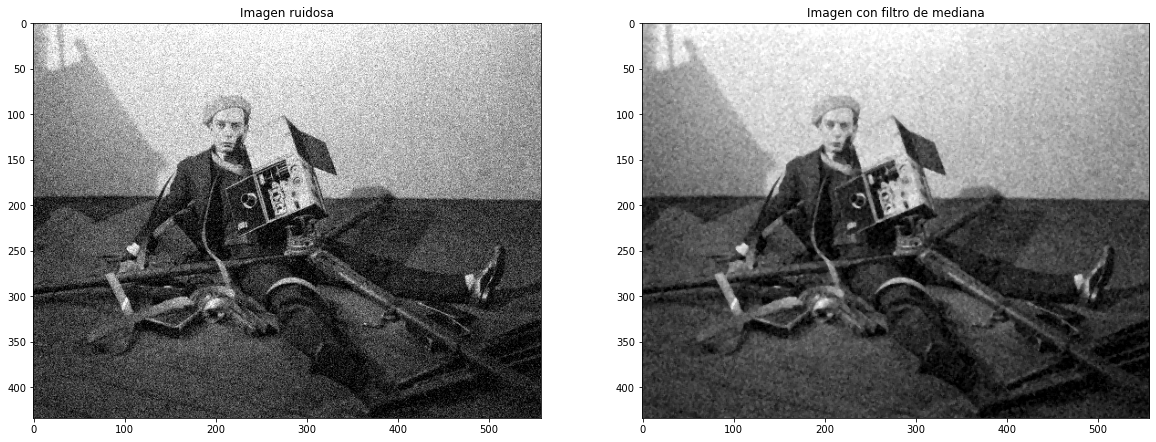

In [16]:
img_mediana = ndimage.median_filter(img_ruidosa, size=3)

fig = plt.figure(figsize=(20,15))

ax1 = fig.add_subplot(121)
ax1.set_title("Imagen ruidosa")

ax2 = fig.add_subplot(122)
ax2.set_title("Imagen con filtro de mediana")

ax1.imshow(img_ruidosa, cmap="gray")
ax2.imshow(img_mediana, cmap="gray")

plt.show()

Se puede apreciar que el ruido ha reducido y no es tan borrosa a comparación de la imagen con el filtro de la media, pero el ruido es más notable.

## Filtro gaussiano

El filtro gaussiano se basa en sustituir el valor de cada pixel con una media ponderada, en la cual, los píxeles vecinos más cercanos al pixel que se está sustituyendo tienen un mayor peso según la distribución de la campana de Gauss. El suavizado viene determinado por $\sigma$, que controla cuántos vecinos se tienen en cuenta.

Reduce de manera eficaz el ruido pero hace que los bordes de la imagen no se distingan bien, haciendo que se vea más borrosa.

Se puede ver en la siguiente demostración:

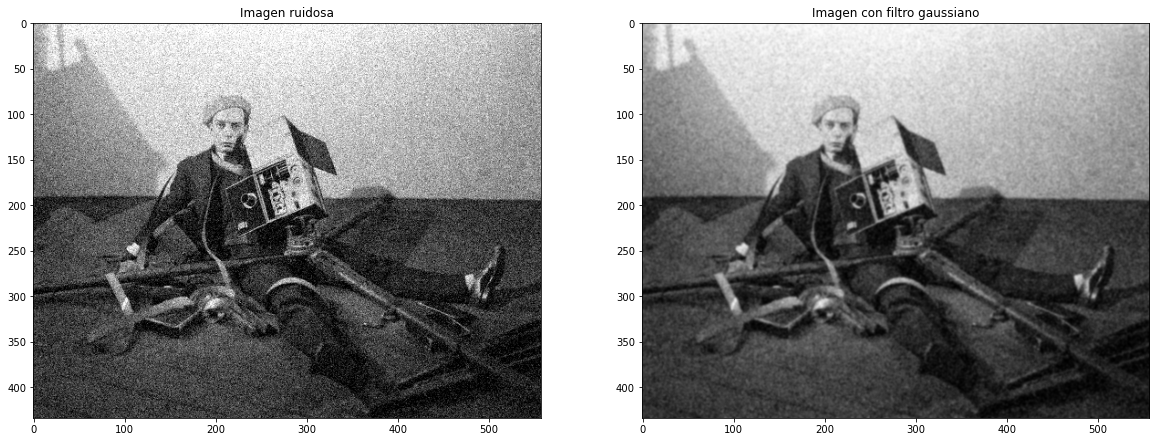

In [17]:
img_gaussiana = ndimage.gaussian_filter(img_ruidosa, sigma=1)

fig = plt.figure(figsize=(20,15))

ax1 = fig.add_subplot(121)
ax1.set_title("Imagen ruidosa")

ax2 = fig.add_subplot(122)
ax2.set_title("Imagen con filtro gaussiano")

ax1.imshow(img_ruidosa, cmap="gray")
ax2.imshow(img_gaussiana, cmap="gray")

plt.show()

# Filtro anisotrópico

El filtro anisotrópico reduce el ruido según la similitud entre los píxeles vecinos. El suavizado no se aplica de forma uniforme sino que se controla mediante una función de similitud la cual depende de las diferencias de intensidad entre el pixel actual y sus vecinos. Se caracteriza por ser iterativo, es decir, poco a poco vamos aplicando el filtro a través de varias iteraciones sobre la imagen.

El ruido se suavizará en zonas uniformes mientras que en los bordes al haber un mayor contraste entre los vecinos, el proceso de suavizado no será tan fuerte evitando así que los bordes sean tan borrosos.

La implementación es la siguiente, en la cual pedimos por parámetro la imagen a la que queremos aplicar el ruido, el nº de iteraciones y la sensibilidad a los bordes.

In [18]:
def filtro_anisotropico(img, iteraciones, sen_bordes):
    
    img_copia = img.copy()
    filas, columnas = img_copia.shape

    for iteracion in range(iteraciones):
        img_aniso = img_copia.copy()

        # Recorremos la imagen
        for i in range(1, filas-1):
            for j in range(1, columnas-1):

                # Pixel actual
                px_actual = img_copia[i, j]

                # Vecinos del pixel actual
                # (cogemos los vecinos en todos los ejes cardinales)
                px_norte = img_copia[i-1, j]
                px_sur   = img_copia[i+1, j]
                px_este  = img_copia[i, j+1]
                px_oeste = img_copia[i, j-1]

                # Calculamos cuanto difiere el pixel actual con
                # sus vecinos
                dif_nor = px_norte - px_actual
                dif_sur = px_sur   - px_actual
                dif_est = px_este  - px_actual
                dif_oes = px_oeste - px_actual

                # Calculamos la similitud de cada pixel vecino con
                # el pixel central (función de similitud)
                sim_nor = np.exp(-(dif_nor / sen_bordes)**2)
                sim_sur = np.exp(-(dif_sur / sen_bordes)**2)
                sim_est = np.exp(-(dif_est / sen_bordes)**2)
                sim_oes = np.exp(-(dif_oes / sen_bordes)**2)

                # Actualizamos el pixel basándonos en los vecinos pero
                # teniendo en cuenta la similitud de cada pixel
                img_aniso[i, j] = px_actual + 0.25 * (
                    sim_nor * dif_nor + sim_sur * dif_sur + sim_est * dif_est + sim_oes * dif_oes)

        img_copia = img_aniso

    return img_copia


Podemos poner a prueba el filtro. Evaluando varios casos el que a mi gusto da un mejor resultado es haciendo un total de 15 iteraciones y estableciendo una sensibilidad a los bordes de 0.10


In [19]:
img_aniso = filtro_anisotropico(img_ruidosa, iteraciones=15, sen_bordes=0.10)


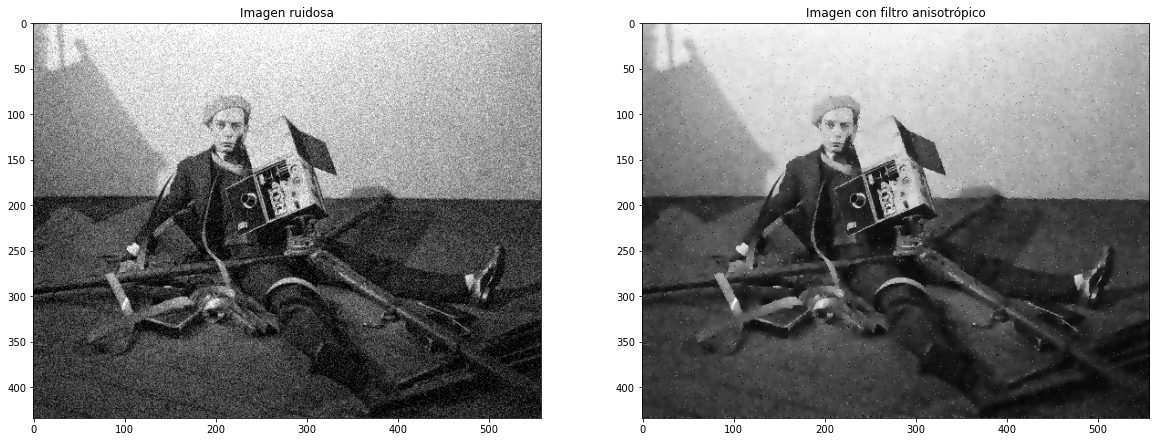

In [20]:
fig = plt.figure(figsize=(20,15))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title("Imagen ruidosa")
ax1.imshow(img_ruidosa, cmap="gray")

ax2.set_title("Imagen con filtro anisotrópico")
ax2.imshow(img_aniso, cmap="gray")

plt.show()

---

# Conclusión

Hemos visto distintos filtros a la hora de reducir el ruido en imágenes.

El filtro de la media y gaussiano son útiles si la imagen tiene ruido muy homogeneo y la definición no es una prioridad, en cambio el de la mediana y el isotrópico, son mejores a la hora de conservar los detalles de la imagen.

Se puede ver que cada uno tiene sus puntos fuertes y puntos débiles luego no es que haya uno mejor que otro, sino que dependiendo de nuestra situación podemos aprovecharnos de sus cualidades y aplicar el que mejor nos convenga.

Incluso podríamos combinar varios teniendo en cuenta las características de cada filtro para obtener un resultado incluso mejor.